<a href="https://colab.research.google.com/github/RajrupaDas/DMHalo/blob/main/DMHalo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.style.use('seaborn-v0_8')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Rotmod_LTG.zip to Rotmod_LTG.zip


In [5]:
import zipfile
import os

zip_path = "Rotmod_LTG.zip"
extract_path = "sparc_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted")

Files extracted


In [6]:
files = os.listdir("sparc_data")
print(len(files))

print(files[:20])

175
['F574-1_rotmod.dat', 'UGC07577_rotmod.dat', 'D631-7_rotmod.dat', 'NGC0891_rotmod.dat', 'UGC06983_rotmod.dat', 'UGC02916_rotmod.dat', 'UGC06399_rotmod.dat', 'NGC0247_rotmod.dat', 'UGC04325_rotmod.dat', 'F568-1_rotmod.dat', 'UGC02885_rotmod.dat', 'UGC05253_rotmod.dat', 'NGC4183_rotmod.dat', 'F563-1_rotmod.dat', 'UGC06917_rotmod.dat', 'UGC07399_rotmod.dat', 'UGC00191_rotmod.dat', 'F583-4_rotmod.dat', 'UGC07559_rotmod.dat', 'UGC00731_rotmod.dat']


In [7]:
selected_files = [
    "NGC2403_rotmod.dat",
    "NGC3198_rotmod.dat",
    "NGC6503_rotmod.dat",
    "NGC5055_rotmod.dat",
    "NGC2903_rotmod.dat"
]

In [8]:
def load_galaxy(file_path):
    data = []

    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('#') or len(line.strip()) == 0:
                continue
            parts = line.split()
            row = list(map(float, parts[:3]))  # r, v_obs, v_err
            data.append(row)

    data = np.array(data)

    r = data[:, 0]
    v_obs = data[:, 1]

    return r, v_obs

In [9]:
galaxies = {}

for f in selected_files:
    path = os.path.join("sparc_data", f)
    r, v = load_galaxy(path)
    galaxies[f] = (r, v)

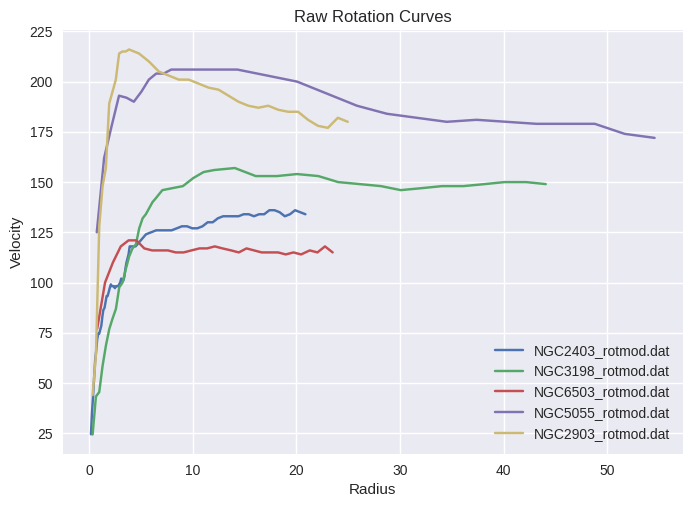

In [10]:
import matplotlib.pyplot as plt

for name, (r, v) in galaxies.items():
    plt.plot(r, v, label=name)

plt.legend()
plt.xlabel("Radius")
plt.ylabel("Velocity")
plt.title("Raw Rotation Curves")
plt.show()

In [11]:
def normalize(r, v):
    r_norm = r / np.max(r)
    v_norm = v / np.max(v)
    return r_norm, v_norm

In [12]:
norm_galaxies = {}

for name, (r, v) in galaxies.items():
    r_n, v_n = normalize(r, v)
    norm_galaxies[name] = (r_n, v_n)

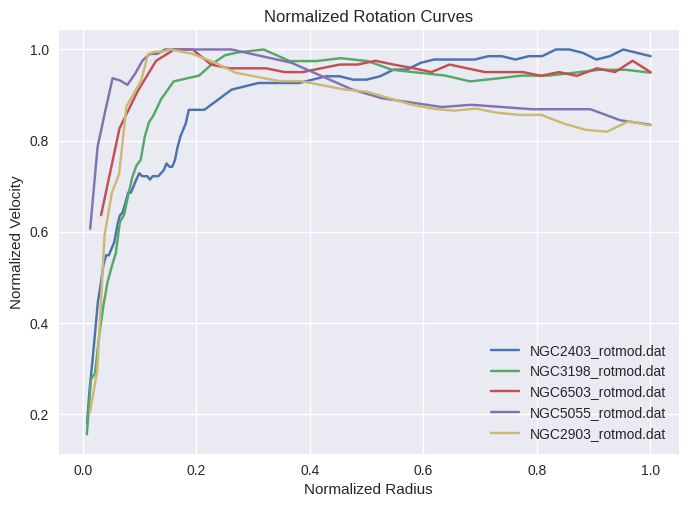

In [13]:
import matplotlib.pyplot as plt

for name, (r, v) in norm_galaxies.items():
    plt.plot(r, v, label=name)

plt.xlabel("Normalized Radius")
plt.ylabel("Normalized Velocity")
plt.legend()
plt.title("Normalized Rotation Curves")
plt.show()

In [14]:
def interpolate_curve(r, v, num_points=100):
    r_new = np.linspace(0, 1, num_points)
    v_new = np.interp(r_new, r, v)
    return r_new, v_new

In [15]:
processed_galaxies = {}

for name, (r, v) in norm_galaxies.items():
    r_i, v_i = interpolate_curve(r, v)
    processed_galaxies[name] = (r_i, v_i)

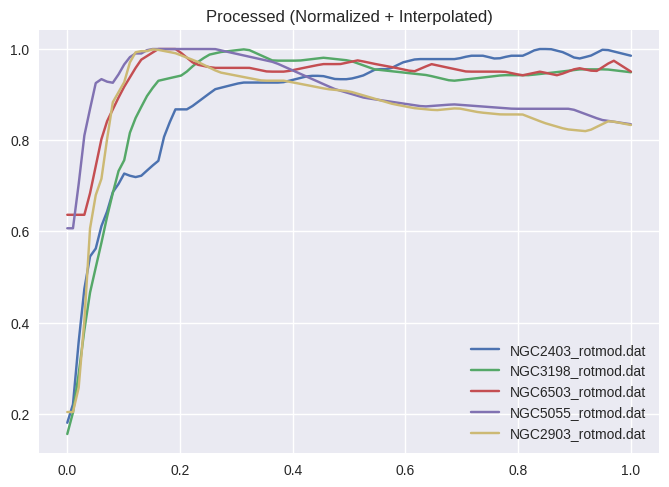

In [16]:
for name, (r, v) in processed_galaxies.items():
    plt.plot(r, v, label=name)

plt.legend()
plt.title("Processed (Normalized + Interpolated)")
plt.show()

In [17]:
import pandas as pd
import os

os.makedirs("data", exist_ok=True)

for name, (r, v) in processed_galaxies.items():
    clean_name = name.replace("_rotmod.dat", ".csv")

    df = pd.DataFrame({
        "r": r,
        "v_obs": v
    })

    df.to_csv(f"data/{clean_name}", index=False)

In [18]:
df = pd.read_csv("data/NGC2403.csv")
print(df.head())
print(len(df))

          r     v_obs
0  0.000000  0.180147
1  0.010101  0.220495
2  0.020202  0.357516
3  0.030303  0.473888
4  0.040404  0.544954
100
